<a href="https://colab.research.google.com/github/Tanish119/main/blob/main/Practical_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [7]:
# Normalize pixel values (0 to 255 → 0 to 1)
x_train = x_train / 255.0
x_test = x_test / 255.0


In [9]:
# Flatten images for Dense network
x_train_flat = x_train.reshape(-1, 28*28)
x_test_flat = x_test.reshape(-1, 28*28)

In [11]:
# Function to build model
def build_model(architecture="simple"):
    model = keras.Sequential()

    if architecture == "simple":
        model.add(layers.Dense(128, activation='relu', input_shape=(784,)))
        model.add(layers.Dense(10, activation='softmax'))

    elif architecture == "deep":
        model.add(layers.Dense(256, activation='relu', input_shape=(784,)))
        model.add(layers.Dense(128, activation='relu'))
        model.add(layers.Dense(64, activation='relu'))
        model.add(layers.Dense(10, activation='softmax'))

    elif architecture == "dropout":
        model.add(layers.Dense(256, activation='relu', input_shape=(784,)))
        model.add(layers.Dropout(0.3))
        model.add(layers.Dense(128, activation='relu'))
        model.add(layers.Dropout(0.3))
        model.add(layers.Dense(10, activation='softmax'))

    return model




In [13]:
# Experiments
architectures = ["simple", "deep", "dropout"]
optimizers = ["adam", "sgd", "rmsprop"]

results = []

for arch in architectures:
    for opt in optimizers:
        print(f"\nTraining Model: {arch} + {opt}")

        model = build_model(arch)

        model.compile(
            optimizer=opt,
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        history = model.fit(
            x_train_flat, y_train,
            epochs=5,
            batch_size=32,
            validation_split=0.2,
            verbose=0
        )

        test_loss, test_acc = model.evaluate(x_test_flat, y_test, verbose=0)

        results.append({
            "Architecture": arch,
            "Optimizer": opt,
            "Test Accuracy": round(test_acc, 4)
        })



Training Model: simple + adam

Training Model: simple + sgd

Training Model: simple + rmsprop

Training Model: deep + adam

Training Model: deep + sgd

Training Model: deep + rmsprop

Training Model: dropout + adam

Training Model: dropout + sgd

Training Model: dropout + rmsprop


In [15]:
# Show Results
df = pd.DataFrame(results)
print("\nFinal Comparison:")
print(df)



Final Comparison:
  Architecture Optimizer  Test Accuracy
0       simple      adam         0.9083
1       simple       sgd         0.1135
2       simple   rmsprop         0.8885
3         deep      adam         0.9461
4         deep       sgd         0.1135
5         deep   rmsprop         0.9370
6      dropout      adam         0.9445
7      dropout       sgd         0.1135
8      dropout   rmsprop         0.9351


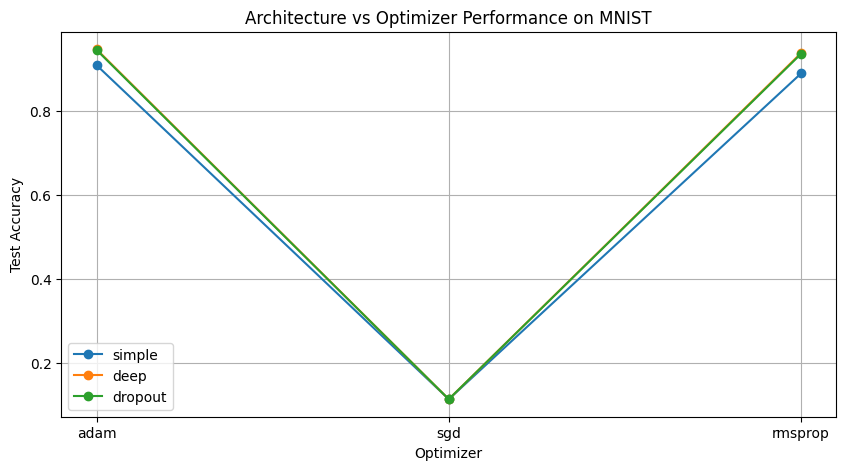

In [16]:
# Plot Results
plt.figure(figsize=(10,5))
for arch in architectures:
    subset = df[df["Architecture"] == arch]
    plt.plot(subset["Optimizer"], subset["Test Accuracy"], marker='o', label=arch)

plt.title("Architecture vs Optimizer Performance on MNIST")
plt.xlabel("Optimizer")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()
